In [11]:
import numpy as np
import matplotlib.pyplot as plt
#ТУТ Я СКОПИПАСТИЛ РЕЗУЛЬАТТ ИЗ ПЕРВОГО ЗАДАНИЯ
#чуешь запах сгенерированного кода? и я нет. а он есть!

3. Эмпирическое распределение и p-value (1 балл)
Цель: промоделировать вычисление порога для заданного уровня значимости.
Задачи:

1. Напишите генератор случайных последовательностей длины L = 9 с частотами генома человека
(A/T : 0.295, G/C : 0.205).
2. Сгенерируйте 100 000 таких "фоновых"последовательностей.
3. Посчитайте скор по вашей PWM для каждой из 100 000 последовательностей.
4. Постройте гистограмму распределения скоров (используя matplotlib.pyplot.hist).
5. Напишите функцию get_pvalue(score), которая возвращает долю фоновых скоров ≥ заданного
score.
6. Найдите, какой порог (threshold) нужно установить, чтобы p-value ≈ 10−4 .

Ответ: Код генерации и расчетов. Построенная гистограмма распределения скоров (изображение). Вы-
численное значение порога для p-value ≈ 10−4 .

In [7]:
pwm = [[-0.23878686, -1.47979496,  1.40062343, -1.47979496, -4.93922658,
        -4.93922658, -0.54690915,  1.21052054, -0.54690915, -1.47979496,
        -0.23878686],
       [ 0.28630419,  1.5166018 , -0.02181811, -0.95470391, -4.41413553,
        -4.41413553,  1.5166018 , -4.41413553, -4.41413553,  1.92571447,
         0.28630419],
       [ 0.28630419, -0.95470391, -4.41413553,  1.92571447,  2.24407595,
        -4.41413553, -4.41413553,  0.54006078,  1.92571447, -4.41413553,
         0.28630419],
       [-0.23878686, -0.54690915, -4.93922658, -4.93922658, -4.93922658,
         1.71898491, -0.54690915, -4.93922658, -4.93922658, -1.47979496,
        -0.23878686]]
pwm

[[-0.23878686,
  -1.47979496,
  1.40062343,
  -1.47979496,
  -4.93922658,
  -4.93922658,
  -0.54690915,
  1.21052054,
  -0.54690915,
  -1.47979496,
  -0.23878686],
 [0.28630419,
  1.5166018,
  -0.02181811,
  -0.95470391,
  -4.41413553,
  -4.41413553,
  1.5166018,
  -4.41413553,
  -4.41413553,
  1.92571447,
  0.28630419],
 [0.28630419,
  -0.95470391,
  -4.41413553,
  1.92571447,
  2.24407595,
  -4.41413553,
  -4.41413553,
  0.54006078,
  1.92571447,
  -4.41413553,
  0.28630419],
 [-0.23878686,
  -0.54690915,
  -4.93922658,
  -4.93922658,
  -4.93922658,
  1.71898491,
  -0.54690915,
  -4.93922658,
  -4.93922658,
  -1.47979496,
  -0.23878686]]

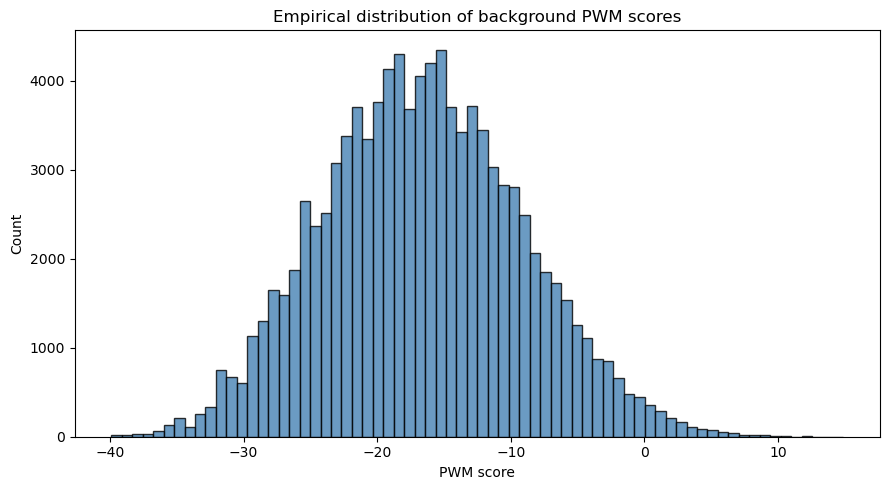

Motif length L = 11
Threshold for p-value ≈ 1e-4: 11.129209249999999
Empirical p-value at threshold: 0.0001


In [9]:
# PWM в порядке строк: A, C, G, T
pwm = np.array([
    [-0.23878686, -1.47979496,  1.40062343, -1.47979496, -4.93922658,
     -4.93922658, -0.54690915,  1.21052054, -0.54690915, -1.47979496,
     -0.23878686],

    [ 0.28630419,  1.5166018 , -0.02181811, -0.95470391, -4.41413553,
     -4.41413553,  1.5166018 , -4.41413553, -4.41413553,  1.92571447,
      0.28630419],

    [ 0.28630419, -0.95470391, -4.41413553,  1.92571447,  2.24407595,
     -4.41413553, -4.41413553,  0.54006078,  1.92571447, -4.41413553,
      0.28630419],

    [-0.23878686, -0.54690915, -4.93922658, -4.93922658, -4.93922658,
      1.71898491, -0.54690915, -4.93922658, -4.93922658, -1.47979496,
     -0.23878686]
])

# Длина мотива определяется по PWM
L = pwm.shape[1]   # здесь L = 11
N = 100_000

# Алфавит в том же порядке, что и строки PWM: A, C, G, T
alphabet = np.array(['A', 'C', 'G', 'T'])
bg_probs = np.array([0.295, 0.205, 0.205, 0.295])  # A, C, G, T

rng = np.random.default_rng(42)

# 1. Генератор случайных последовательностей
def generate_random_sequences(n, L):
    return rng.choice(alphabet, size=(n, L), p=bg_probs)

# 2. Генерация 100000 фоновых последовательностей
seqs = generate_random_sequences(N, L)

# 3. Подсчет PWM-скоров
base_to_idx = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
seq_idx = np.vectorize(base_to_idx.get)(seqs)   # shape (N, L)
col_idx = np.arange(L)
scores = pwm[seq_idx, col_idx].sum(axis=1)

# 4. Гистограмма распределения скоров
plt.figure(figsize=(9, 5))
plt.hist(scores, bins=70, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('PWM score')
plt.ylabel('Count')
plt.title('Empirical distribution of background PWM scores')
plt.tight_layout()
plt.show()

# 5. Функция p-value
scores_sorted = np.sort(scores)

def get_pvalue(score):
    # доля фоновых скоров >= score
    pos = np.searchsorted(scores_sorted, score, side='left')
    return (len(scores_sorted) - pos) / len(scores_sorted)

# 6. Поиск порога для p-value ≈ 1e-4
target_p = 1e-4

# Берем минимальный threshold, для которого p-value <= 1e-4
unique_scores = np.unique(scores_sorted)
pvals = np.array([get_pvalue(x) for x in unique_scores])

mask = pvals <= target_p
threshold = unique_scores[mask][0]

print("Motif length L =", L)
print("Threshold for p-value ≈ 1e-4:", threshold)
print("Empirical p-value at threshold:", get_pvalue(threshold))
